:::{canonical-tutorial} tutorials/basics/clustering

Based on:

| Version | Description | Link |
| :--- | :--- | :--- |
| **Stable** | Modern best practices for clustering | [View Tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html) |
| **2017** | Classic workflow (Satija et al. style) | [View Tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering-2017.html) |

# Preprocessing and clustering

In [1]:
# Core scverse libraries
#from __future__ import annotations
import anndata as ad
import scanpy as sc
import os
from pathlib import Path
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.settings.set_figure_params(dpi=50, facecolor="white")
sc.set_figure_params(dpi=50, facecolor="white")
sc.logging.print_header()

Package,Version
anndata,0.12.11
scanpy,1.12.1
scipy,1.17.1
pandas,2.3.3
matplotlib,3.10.9
Component,Info
Python,"3.13.13 | packaged by conda-forge | (main, Apr 8 2026, 02:19:32) [Clang 19.1.7 ]"
OS,macOS-14.4.1-x86_64-i386-64bit-Mach-O
CPU,"16/16 logical CPU cores, i386"
GPU,No GPU found


In [3]:
# Working directory
#wd = os.getcwd()
wd = Path.cwd()
an = wd.name  # last folder name
print(f"Working directory: {wd}")
print(f"Analysis name: {an}")

Working directory: /Users/gustavo/Documents/analyses/ga_an0719_Tseng_10x_gex_atac_exvivo_p14_gp33_stim/cd8_rna_clustering_pc20_hvg2000
Analysis name: cd8_rna_clustering_pc20_hvg2000


In [4]:
# Define parameters
params = {
    #"proc": Path("/Users/gustavo/Documents/analyses/ga_an0719_Tseng_10x_gex_atac_exvivo_p14_gp33_stim/cd8_rna_clustering_pc20_hvg2000/cd8_rna_clustering_adata.h5ad"),
    "pc": 20,
    "nn": 100,
    "res": 0.2,
    "n_hvg": 2000
}

In [5]:
# Get example dataset (in bash)
# #%%bash
#test -f pbmc3k_filtered_gene_bc_matrices.tar.gz || curl https://cf.10xgenomics.com/samples/cell/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -o pbmc3k_filtered_gene_bc_matrices.tar.gz
#tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz

# # Load example dataset
# adata = sc.read_10x_mtx(
#     "/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/procdata/analysis/filtered_gene_bc_matrices/hg19/",  # the directory with the `.mtx` file
#     var_names="gene_symbols",  # use gene symbols for the variable names (variables-axis index)
#     cache=False,  # write a cache file for faster subsequent reading
# )

In [6]:
# Define data paths
dir=Path("/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/GSE268161_RAW/")
data_dirs = {
    "naive_d4": dir / "naive_d4",
    "activated_d1": dir / "activated_d1",
    "exhausted_d3": dir / "exhausted_d3",
    "exhausted_d4": dir / "exhausted_d4"
}
# data_dirs = {
#     "naive_d4":"/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/GSE268161_RAW/naive_d4",
#     "activated_d1":"/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/GSE268161_RAW/activated_d1",
#     "exhausted_d3":"/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/GSE268161_RAW/exhausted_d3",
#     "exhausted_d4":"/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/GSE268161_RAW/exhausted_d4"
# }

In [7]:
# # Load from the directory containing the three files
# #adata = sc.read_10x_mtx('/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/GSE268161_RAW/activated_d1')

# # Load each dataset
# adata_list = []
# for data_dir in data_dirs:
#     if os.path.exists(data_dir):
#         # Load the 10x matrix market format
#         adata = sc.read_10x_mtx(data_dir)
        
#         # Make gene names unique
#         adata.var_names_make_unique()
        
#         # Add sample identifier for tracking
#         sample_name = os.path.basename(data_dir.rstrip('/'))
#         adata.obs['sample'] = sample_name
        
#         adata_list.append(adata)
#         print(f"Loaded {sample_name}: {adata.shape}")

# # Concatenate all samples
# if adata_list:
#     adata = sc.concat(adata_list, keys=[os.path.basename(d.rstrip('/')) for d in data_dirs])
    
#     # Ensure unique gene names across all samples
#     adata.var_names_make_unique()
    
#     print(f"Combined dataset shape: {adata.shape}")
#     print(f"Samples: {adata.obs['sample'].unique()}")
# else:
#     print("No valid data directories found")

# # This does not work because the features.tsv files has only one column with gene symbols (it misses the first column with gene IDs).

In [8]:
# Define function lo load data
def read_10x_mtx_single_column(path):
    """Read 10x matrix market format where features.tsv has only 1 column (gene symbols)"""
    
    # Read matrix
    mtx = scipy.io.mmread(f"{path}/matrix.mtx.gz").T.tocsr()
    
    # Read barcodes
    barcodes = pd.read_csv(f"{path}/barcodes.tsv.gz", header=None, sep="\t", compression='gzip')[0].values
    
    # Read features (gene symbols only)
    features = pd.read_csv(f"{path}/features.tsv.gz", header=None, sep="\t", compression='gzip')[0].values
    
    # Create AnnData object
    adata = ad.AnnData(X=mtx, 
                       obs=pd.DataFrame(index=barcodes), 
                       var=pd.DataFrame(index=features))
    
    return adata

# Load each dataset
adata_list = []
for name, data_dir in data_dirs.items():
    if os.path.exists(data_dir):
        adata = read_10x_mtx_single_column(data_dir)
        adata.obs_names_make_unique()
        adata.var_names_make_unique()
        adata.obs['sample'] = name
        adata_list.append(adata)
        print(f"Loaded {name}: {adata.shape}")

# Create unique barcodes
for label, ads in zip(data_dirs.keys(), adata_list):
    ads.obs_names = [f"{label}_{bc}" for bc in ads.obs_names]

# Concatenate all samples
if adata_list:
    adata = sc.concat(adata_list, keys=list(data_dirs.keys()))
    #adata = sc.concat(adata_list, keys=list(data_dirs.keys()), label="sample", index_unique="_")
    #adata.obs_names_make_unique()
    #adata.var_names_make_unique()
    print(f"Combined dataset shape: {adata.shape}")

Loaded naive_d4: (10172, 32285)
Loaded activated_d1: (9735, 32285)
Loaded exhausted_d3: (20000, 32285)
Loaded exhausted_d4: (15365, 32285)
Combined dataset shape: (55272, 32285)


In [ ]:
# Load barcodes to keep
with open(Path("/Users/gustavo/Documents/analyses/ga_an0682_10x_gex_exvivo_p14_gp33_stim_mgd/ga_an0682_10x_gex_exvivo_p14_gp33_stim_mgd_filtered_cell_barcodes.txt")) as f:
    keep_barcodes = set(line.strip() for line in f)

print(list(adata.obs_names[:5]))
print(list(keep_barcodes)[:5])

['naive_d4_AAACAGCCACCTCAGG-1', 'naive_d4_AAACAGCCATGAATCT-1', 'naive_d4_AAACATGCAAACCTTG-1', 'naive_d4_AAACATGCAACTAGGG-1', 'naive_d4_AAACATGCAATAGCCC-1']
['exhausted_d3_GGTGAGGTCCTGTTCA-1', 'exhausted_d4_TGATGACTCGCTAGCA-1', 'exhausted_d4_GCACGAACATCATGGC-1', 'exhausted_d3_CAAACAACAGGACCTT-1', 'exhausted_d3_TTTAGCTTCGCTTGCT-1']


In [10]:
# Filter barcodes
adata = adata[adata.obs_names.isin(keep_barcodes)].copy()
print(f"Filtered dataset shape: {adata.shape}")

Filtered dataset shape: (42590, 32285)


## Quality Control

In [11]:
# mtchondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("mt-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
## hemoglobin genes
#adata.var["hb"] = adata.var_names.str.contains("^Hp[^(p)]")

In [12]:
# Calculate common metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

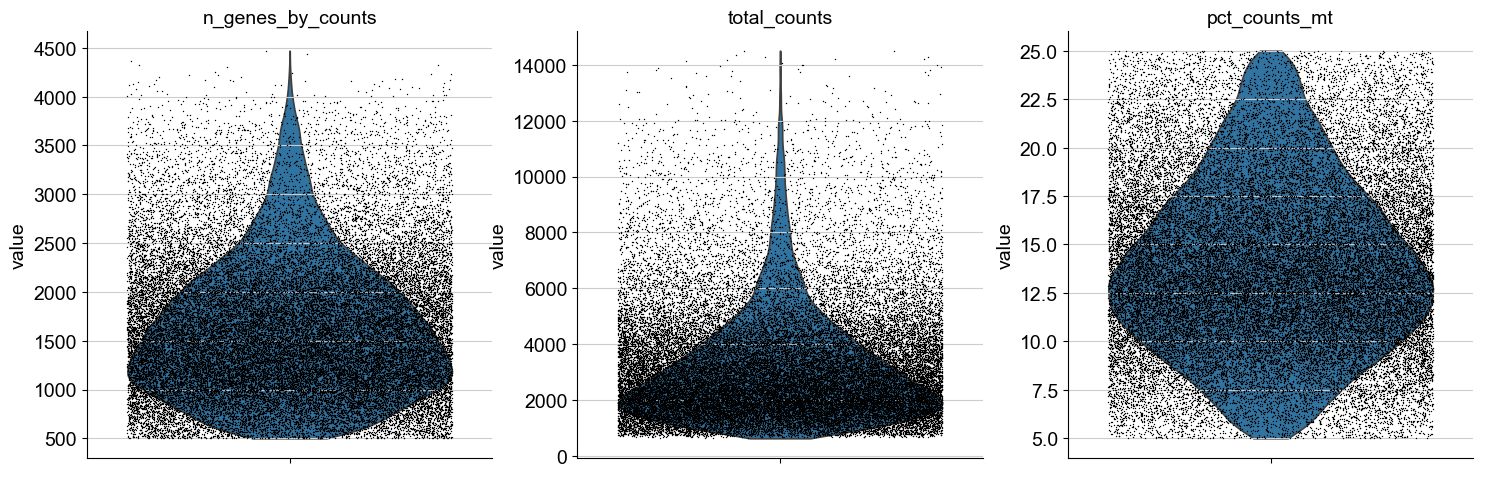

In [13]:
# Inspect computed QC metrics
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

<Axes: title={'center': 'pct counts mt'}, xlabel='total_counts', ylabel='n_genes_by_counts'>

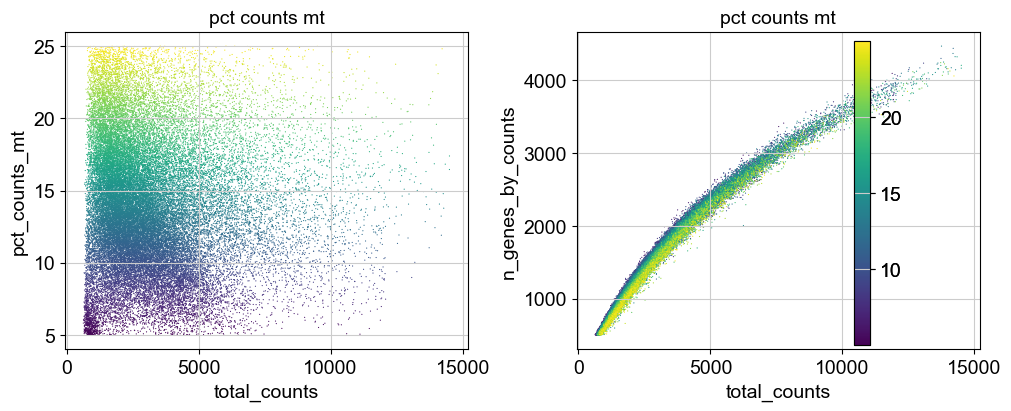

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", color="pct_counts_mt", show=False, ax=axs[0])
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt", show=False, ax=axs[1])

normalizing counts per cell
    finished (0:00:02)


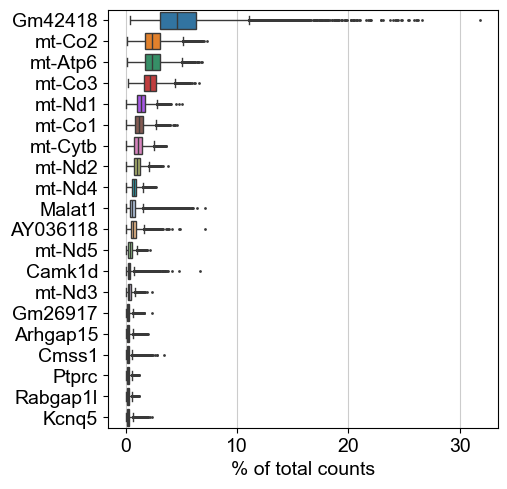

In [15]:
# Show those genes that yield the highest fraction of counts in each single cell, across all cells
sc.pl.highest_expr_genes(adata, n_top=20)

In [16]:
# # Filter base on QC plots
# sc.pp.filter_cells(adata, min_genes=100)
# sc.pp.filter_genes(adata, min_cells=3)
# adata = adata[
#     (adata.obs.n_genes_by_counts < 2500) & (adata.obs.n_genes_by_counts > 200) & (adata.obs.pct_counts_mt < 5),
#     :,
# ].copy()
# adata.layers["counts"] = adata.X.copy()
# adata.X[:2, :50].toarray()

In [17]:
# # Run a doublet detection algorithm
# sc.pp.scrublet(adata, batch_key="sample")

## Normalization

In [18]:
# Save raw counts data
adata.layers["counts"] = adata.X.copy()

In [19]:
# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [20]:
# Only include the most informative genes
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=params["n_hvg"], batch_key="sample", check_values=True)
#sc.pp.highly_variable_genes(adata, layer="counts", flavor="seurat_v3", n_top_genes=2000, batch_key="sample", check_values=True)
#sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000, batch_key="sample")

extracting highly variable genes
    finished (0:00:04)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


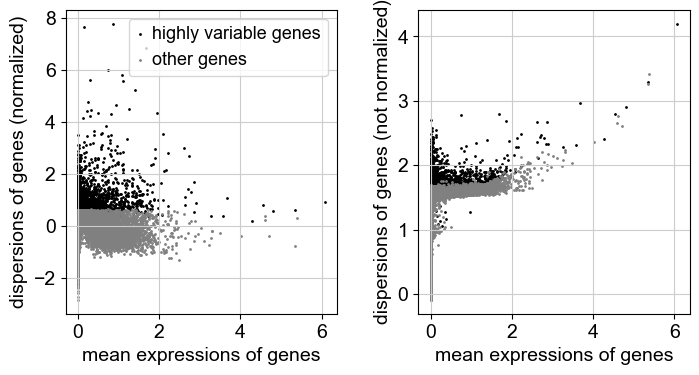

In [21]:
sc.pl.highly_variable_genes(adata)

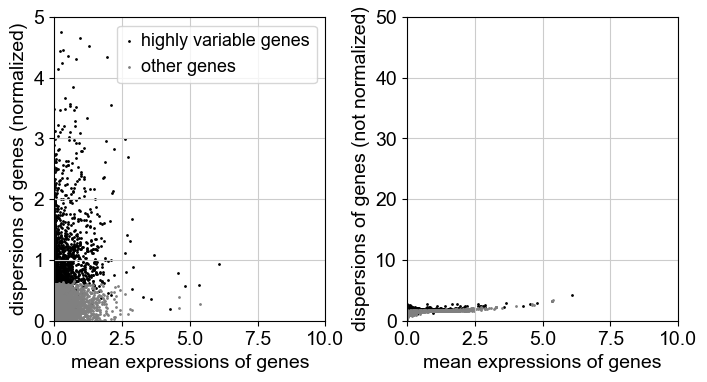

In [22]:
# ax = sc.pl.highly_variable_genes(
#     adata,
#     show=False
# )
# ax[0].set_xlim(0, 50)
# ax[0].set_ylim(0, 5)
# ax[1].set_xlim(0, 50)
# ax[1].set_ylim(0, 2000)
# plt.show()

# axs = sc.pl.highly_variable_genes(adata, show=False)
# for ax in axs:
#     ax.set_xlim(0, 5)
#     ax.set_ylim(0, 10)
# plt.show()

sc.pl.highly_variable_genes(adata, show=False)
fig = plt.gcf()
axs = fig.axes
axs[0].set_xlim(0, 10)
axs[0].set_ylim(0, 5)
axs[1].set_xlim(0, 10)
axs[1].set_ylim(0, 50)

plt.show()

In [23]:
# adata2 = adata.copy()
# sc.pp.highly_variable_genes(adata2, flavor="seurat", n_top_genes=2000, batch_key="sample")
# sc.pl.highly_variable_genes(adata2)

## Dimensionality Reduction

In [24]:
# Create scaled data layer
adata.layers["scaled"] = adata.X.toarray()

## Regress out the effect of total counts and mitochondrial percentage
#sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"], layer="scaled")

# Scale each gene to unit variance
sc.pp.scale(adata, max_value=10, layer="scaled")

In [25]:
# Reduce the dimensionality of the data by running principal component analysis (PCA), which reveals the main axes of variation and denoises the data.
#sc.tl.pca(adata)
sc.tl.pca(adata, n_comps=50, layer="scaled", svd_solver="arpack", mask_var="highly_variable")
#sc.tl.pca(adata, n_comps=50, svd_solver="randomized", mask_var="highly_variable")

computing PCA
    with n_comps=50
    finished (0:00:15)


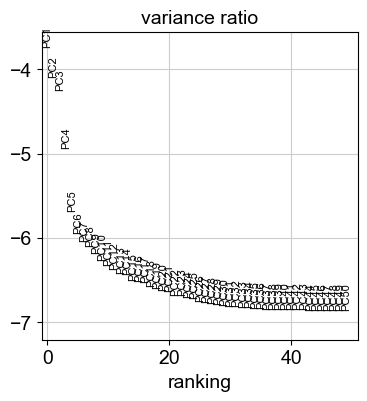

In [26]:
# Inspect the contribution of single PCs to the total variance in the data
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

/Users/gustavo/Documents/ngs/github/netmap/.pixi/envs/default/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


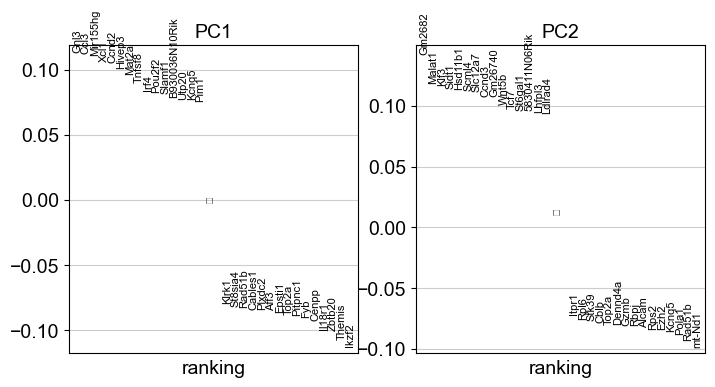

In [27]:
sc.pl.pca_loadings(adata, components=(1, 2), include_lowest=True)

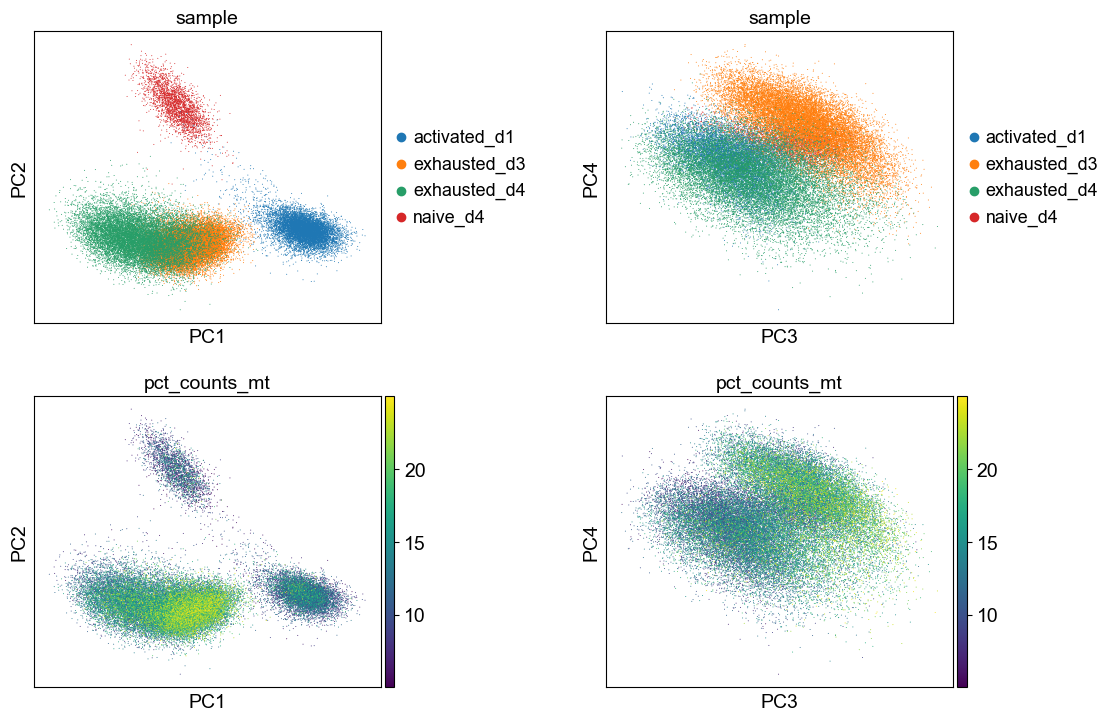

In [28]:
# Plot the principal components
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0,1), (2,3), (0,1), (2,3)],
    wspace=0.5,
    ncols=2,
    size=2,
)

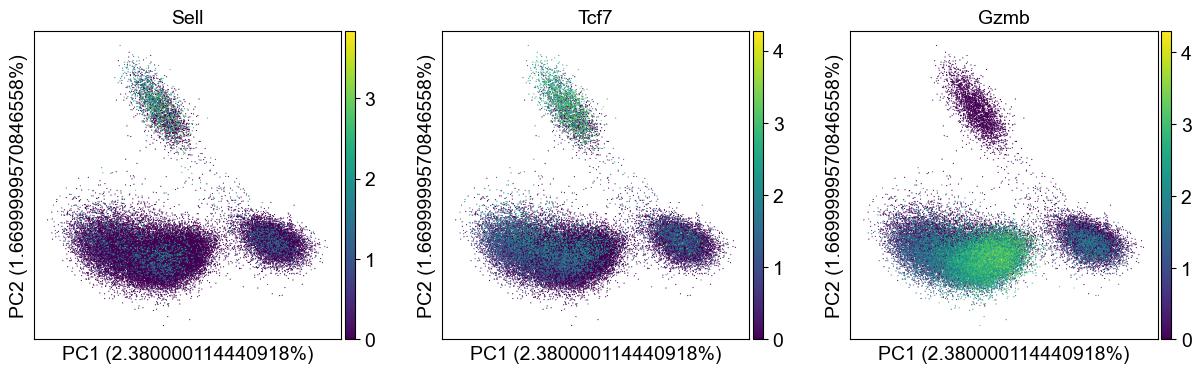

In [29]:
sc.pl.pca(adata, annotate_var_explained=True, color=["Sell", "Tcf7", "Gzmb"])

In [30]:
# # Save object
# #adata.write_h5ad('/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/procdata/analysis/cd8_rna_clustering_adata_pre.h5ad', compression='gzip')
# adata.write_h5ad(wd / f"{an}_adata_pre.h5ad", compression="gzip")

In [31]:
# # Reload processed data
# #adata = sc.read_h5ad('/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/procdata/analysis/cd8_rna_clustering_adata_pre.h5ad')
# adata = sc.read_h5ad(wd / f"{an}_adata_pre.h5ad")

## Nearest neighbor graph construction and visualization

In [32]:
#sc.pp.neighbors(adata)
sc.pp.neighbors(adata, n_neighbors=params["nn"], n_pcs=params["pc"])
#sc.pp.neighbors(adata, key_added="neighbors", n_neighbors=100, n_pcs=20)
## This is needed due to a current bug
#adata.obsp['neighbors']['distances'] = adata.obsp['neighbors_distances']
#adata.uns['neighbors']['connectivities'] = adata.obsp['neighbors_connectivities']

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:49)


In [33]:
# # Run umap on PAGA graph layout
# adata.uns['neighbors']['distances'] = adata.obsp['distances']
# adata.uns['neighbors']['connectivities'] = adata.obsp['connectivities']
# sc.tl.paga(adata)
# sc.pl.paga(adata, plot=False)  # remove `plot=False` if you want to see the coarse-grained graph
# sc.tl.umap(adata, init_pos='paga')
# sc.pl.umap(adata, color="sample", size=2)

In [34]:
# Embedded graph in two dimensions for visualiztion with UMAP
sc.tl.umap(adata, method="umap", min_dist=0.5, spread=1.0, random_state=0)
#sc.tl.umap(adata, method="umap", key_added="umap", neighbors_key="neighbors", min_dist=0.5, spread=1.0, random_state=0)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:46)


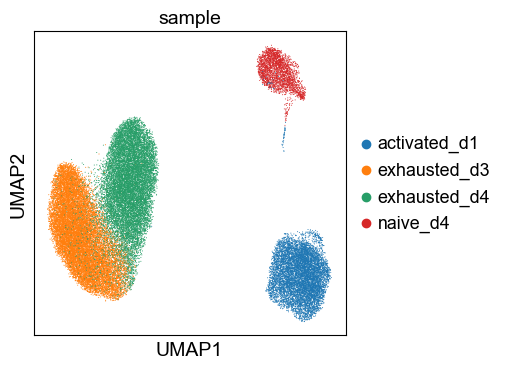

In [35]:
# Visualize the UMAP
sc.pl.umap(
    adata,
    color="sample",
    size=2,
)

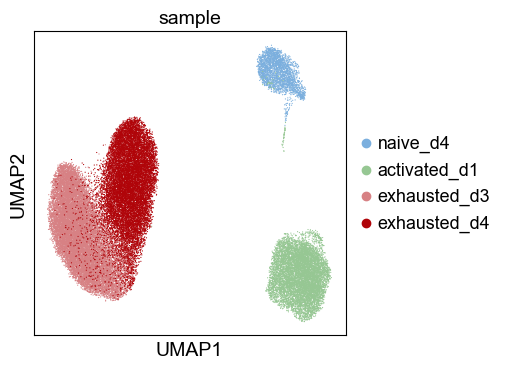

In [36]:
# Ensure the column is a 'category' type
adata.obs['sample'] = adata.obs['sample'].astype('category')

# Reorder the categories in the 'sample' column
adata.obs['sample_old'] = adata.obs['sample'].copy()
new_order_sp = ['naive_d4', 'activated_d1', 'exhausted_d3', 'exhausted_d4']
adata.obs['sample'] = adata.obs['sample'].cat.set_categories(new_order_sp, ordered=True)

# Create color dictionary
color_dict_sp = {
    "naive_d4": "#7BAFDE",  # blue
    "activated_d1": "#96C793",  # green
    "exhausted_d3": "#D78184",  # red
    "exhausted_d4": "#b00409"   # dark red
}

# Map the dictionary to the category order
adata.uns['sample_colors'] = [color_dict_sp[cat] for cat in adata.obs['sample'].cat.categories]

# Plot to verify
sc.pl.umap(adata, color='sample')


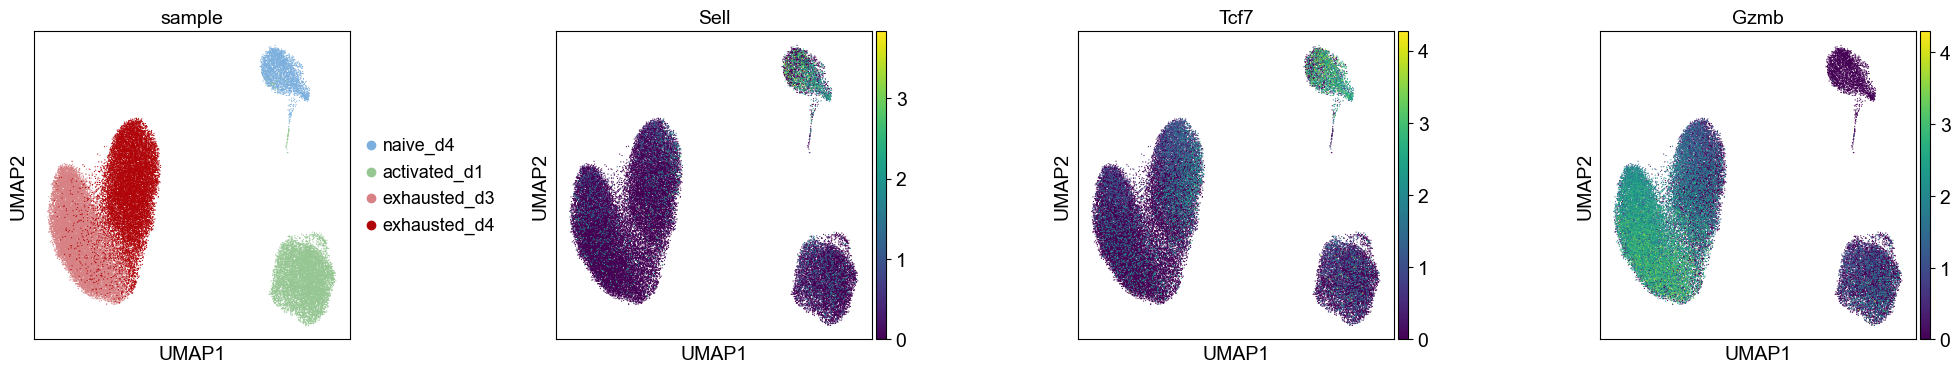

In [37]:
# Plot expression over the umap
sc.pl.umap(adata, color=["sample","Sell", "Tcf7", "Gzmb"], wspace=0.5)
#sc.pl.umap(adata, color=["Sell", "Tcf7", "Gzmb"], layer="counts")
#sc.pl.umap(adata, color=["Sell", "Tcf7", "Gzmb"], layer="scaled")

## Clustering

In [38]:
# # Test different resolutions
# for res in [0.02, 0.2, 0.5, 1]:
#     sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph", random_state=0, n_iterations=-1, directed=False)
# sc.pl.umap(
#     adata,
#     color=["leiden_res_0.02", "leiden_res_0.20", "leiden_res_0.50", "leiden_res_1.00"],
#     legend_loc="on data",
# )

In [39]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
#sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
sc.tl.leiden(
    adata,
    resolution=params["res"],
    random_state=0,
    flavor="igraph",
    n_iterations=-1,
    directed=False
)
#adata.obs["leiden"] = adata.obs["leiden"].copy()
#adata.uns["leiden"] = adata.uns["leiden"].copy()
#adata.obsm["X_umap"] = adata.obsm["X_umap"].copy()
##adata.obsm["umap"] = adata.obsm["umap"].copy()

running Leiden clustering
    finished: found 4 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:36)


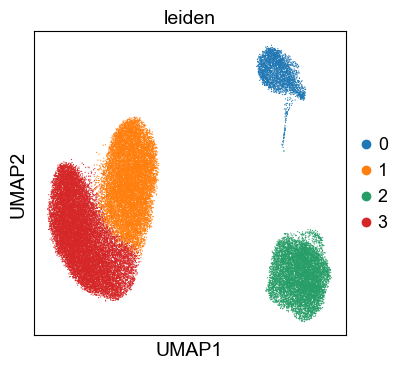

In [40]:
# Plot clusters
sc.pl.umap(adata, color=["leiden"])
#sc.pl.umap(adata, color=["leiden"], show).figure.savefig("output_path.ext")

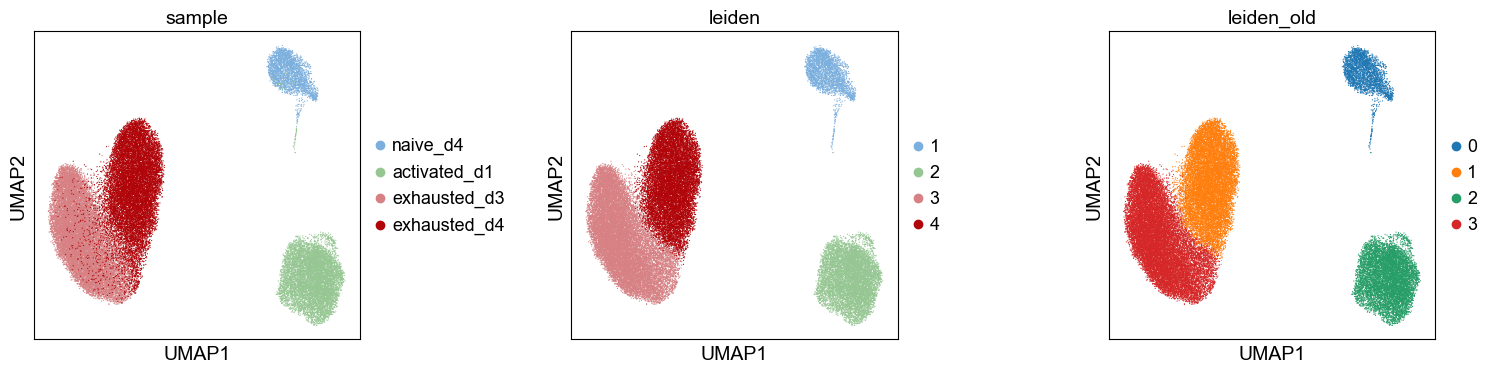

In [41]:
# Ensure the column is a 'category' type
adata.obs['leiden'] = adata.obs['leiden'].astype('category')

# Create cluster mapping
mapping_cl = {
    "0": "1",
    "1": "4",
    "2": "2",
    "3": "3"
}

# Apply the mapping to a new column to keep the original data safe
adata.obs['leiden_old'] = adata.obs['leiden'].copy()
adata.obs['leiden'] = adata.obs['leiden'].map(mapping_cl).astype('category')

# Reorder the categories in the 'sample_names' column
new_order_cl = ['1', '2', '3', '4']
adata.obs['leiden'] = adata.obs['leiden'].cat.set_categories(new_order_cl, ordered=True)

# Create color dictionary
color_dict_cl = {   
    "1": "#7BAFDE",
    "2": "#96C793",
    "3": "#D78184",
    "4": "#b00409"
    #"5": "#000000",
    #"6": "#000000",
    #"7": "#000000",
    #"8": "#000000"
}

# Map the dictionary to the category order
adata.uns['leiden_colors'] = [color_dict_cl[cat] for cat in adata.obs['leiden'].cat.categories]

# Plot to verify
sc.pl.umap(adata, color=["sample", "leiden", "leiden_old"], wspace=0.5)


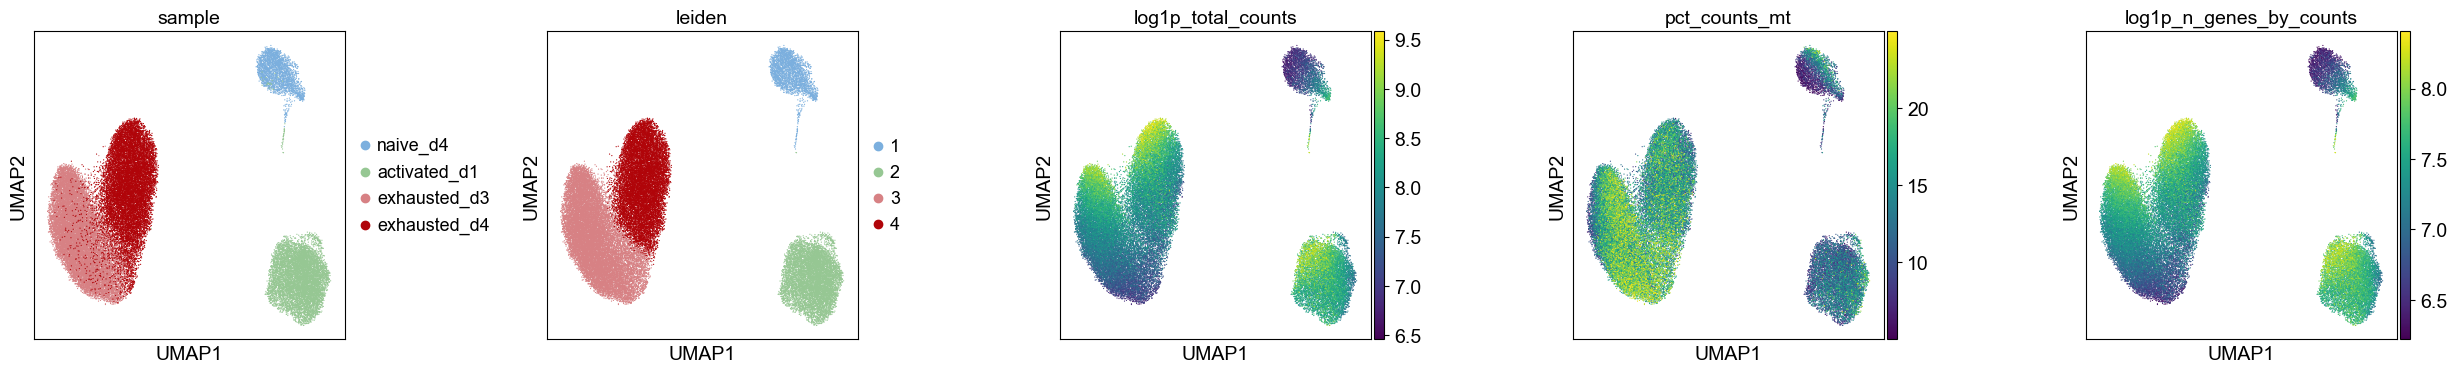

In [42]:
sc.pl.umap(
    adata,
    #color=["leiden", "predicted_doublet", "doublet_score"],
    color=["sample", "leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=5,
    size=3,
)

In [43]:
# Save object
#adata.write_h5ad('/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/procdata/analysis/cd8_rna_clustering_adata.h5ad', compression='gzip')
adata.write_h5ad(wd / f"{an}_adata.h5ad", compression="gzip")

In [44]:
# # Reload processed data
# # adata = sc.read_h5ad('/Users/gustavo/Documents/ngs/pubdata/PRJNA1114784_Tseng_2025/procdata/analysis/cd8_rna_clustering_adata.h5ad')
# adata = sc.read_h5ad(wd / f"{an}_adata.h5ad")

## Manual cell-type annotation

### Marker gene set

Adapted from [Single Cell Best Practices annotation chapter](https://www.sc-best-practices.org/cellular_structure/annotation.html).

In [45]:
# # Define a set of marker genes for the main cell types that we expect to see in this dataset
# marker_genes = {
#     "CD14+ Mono": ["FCN1", "CD14", "LYZ"],
#     "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN", "MS4A7"],
#     # Note: DMXL2 should be negative
#     "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
#     "Erythroblast": ["MKI67", "HBA1", "HBB"],
#     "Megakaryocytes": ["PPBP"],
#     # Note HBM and GYPA are negative markers
#     "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
#     "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
#     "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
#     "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
#     # Note IGHD and IGHM are negative markers
#     "B cells": [
#         "MS4A1",
#         "ITGB1",
#         "COL4A4",
#         "PRDM1",
#         "IRF4",
#         "PAX5",
#         "BCL11A",
#         "BLK",
#         "IGHD",
#         "IGHM",
#     ],
#     "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
#     # Note PAX5 is a negative marker
#     "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
#     "CD4+ T": ["CD4", "IL7R", "TRBC2"],
#     "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
#     "T naive": ["LEF1", "CCR7", "TCF7"],
#     "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
# }

In [46]:
# # Define a set of marker genes for the main cell types (Mouse Orthologs)
# marker_genes = {
#     "CD14+ Mono": ["Fcn1", "Cd14", "Lyz"],
#     "CD16+ Mono": ["Tcf7l2", "Fcgr4", "Lyn", "Ms4a7"],  # Fcgr4 is the functional ortholog of human FCGR3A (CD16)
#     # Note: Dmxl2 should be negative
#     "cDC2": ["Cst3", "Cotl1", "Lyz2", "Dmxl2", "Clec10a", "Fcer1a"],
#     "Megakaryocytes": ["Ppbp"],
#     "Erythroblast": ["Mki67", "Hba-a1", "Hbb-bs"],
#     # Note Hbm and Gypa are negative markers
#     "Proerythroblast": ["Cdk6", "Syngr1", "Hbm", "Gypa"],
#     "NK": ["Gnly", "Nkg7", "Cd247", "Fcer1g", "Tyrobp", "Klrg1", "Fcgr4"],
#     "ILC": ["Id2", "Plcg2", "Gnly", "Syne1"],
#     "Naive CD20+ B": ["Ms4a1", "Il4r", "Ighd", "Fcrl1", "Ighm"],
#     # Note Ighd and Ighm are negative markers
#     "B cells": [
#         "Ms4a1",
#         "Itgb1",
#         "Col4a4",
#         "Prdm1",
#         "Irf4",
#         "Pax5",
#         "Bcl11a",
#         "Blk",
#         "Ighd",
#         "Ighm",
#     ],
#     "Plasma cells": ["Mzb1", "Hsp90b1", "Fndc3b", "Prdm1", "Igkc", "Jchain"],
#     # Note Pax5 is a negative marker
#     "Plasmablast": ["Xbp1", "Prdm1", "Pax5"],
#     "CD4+ T": ["Cd4", "Il7r", "Trbc2"],
#     "CD8+ T": ["Cd8a", "Cd8b1", "Gzmk", "Gzma", "Ccl5", "Gzmb", "Gzmh", "Gzma"],
#     "T naive": ["Lef1", "Ccr7", "Tcf7"],
#     "pDC": ["Gzmb", "Il3ra", "Cobll1", "Tcf4"],
# }

# # Identify and delete genes not present in adata.var_names
# original_genes = set(gene for genes in marker_genes.values() for gene in genes)
# marker_genes = {
#     cell: [gene for gene in genes if gene in adata.var_names]
#     for cell, genes in marker_genes.items()
# }

# # Identify and print the deleted genes as a vector (list)
# remaining_genes = set(gene for genes in marker_genes.values() for gene in genes)
# deleted_genes = list(original_genes - remaining_genes)

# print(f"Deleted genes: {deleted_genes}")

In [47]:
# Define a set of marker genes for the main cell types (Mouse Orthologs)
marker_genes = {
    #"CD8+ T": ["Cd8a", "Cd8b1", "Gzmk", "Gzma", "Ccl5", "Gzmb", "Gzmh", "Gzma"],
    "naive": ["Lef1", "Sell", "Ccr7", "Tcf7"],
    "activated": ["Ccl3", "Ccl4", "Ifng", "Cd69", "Il2ra", "Tnf", "Hla-Dr1"],
    #"effector": ['Ccl3','Ccl4','Ccl5','Gzma','Gzmb','Gzmc','Gzmk','Gzmm','Ifng','Prf1','Ctsd','Ctsw','Tnf','Nkg7','Klrg1','Cd40lg','Tgfb1','Tgfb2','Tgfb3','Csf1','Csf2','Lif','Osm','Lta'],
    "exhausted": ['Cd200r1','Cxcr3','Ctla4','Dusp4','Ikzf2','Havcr2','Hells','Lag3','Mt1','Mt2','Myb','Nr4a1','Nr4a2','Pbx3','Pdcd1','Rgs16','Tigit','Tnfrsf9','Xcl1','Tox'],
}

# Identify and delete genes not present in adata.var_names
original_genes = set(gene for genes in marker_genes.values() for gene in genes)
marker_genes = {
    cell: [gene for gene in genes if gene in adata.var_names]
    for cell, genes in marker_genes.items()
}

# Identify and print the deleted genes as a vector (list)
remaining_genes = set(gene for genes in marker_genes.values() for gene in genes)
deleted_genes = list(original_genes - remaining_genes)

print(f"Deleted genes: {deleted_genes}")

Deleted genes: ['Hla-Dr1']


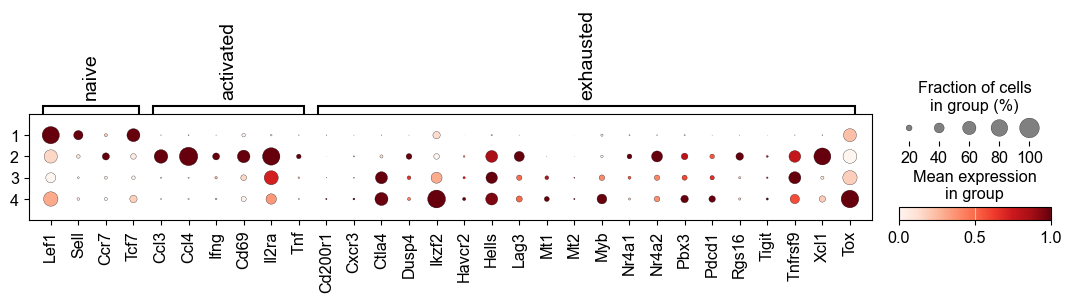

In [48]:
# Plot expression
sc.pl.dotplot(adata, marker_genes, groupby="leiden", standard_scale="var")

In [49]:
# # Annotate clusters based on marker gene expression
# adata.obs["cell_type"] = adata.obs["leiden"].map(
#     {
#         "1": "naive",
#         "2": "activated",
#         "3": "exhausted",
#         "4": "exhausted",
#     }
# )

### Differentially-expressed Genes as Markers

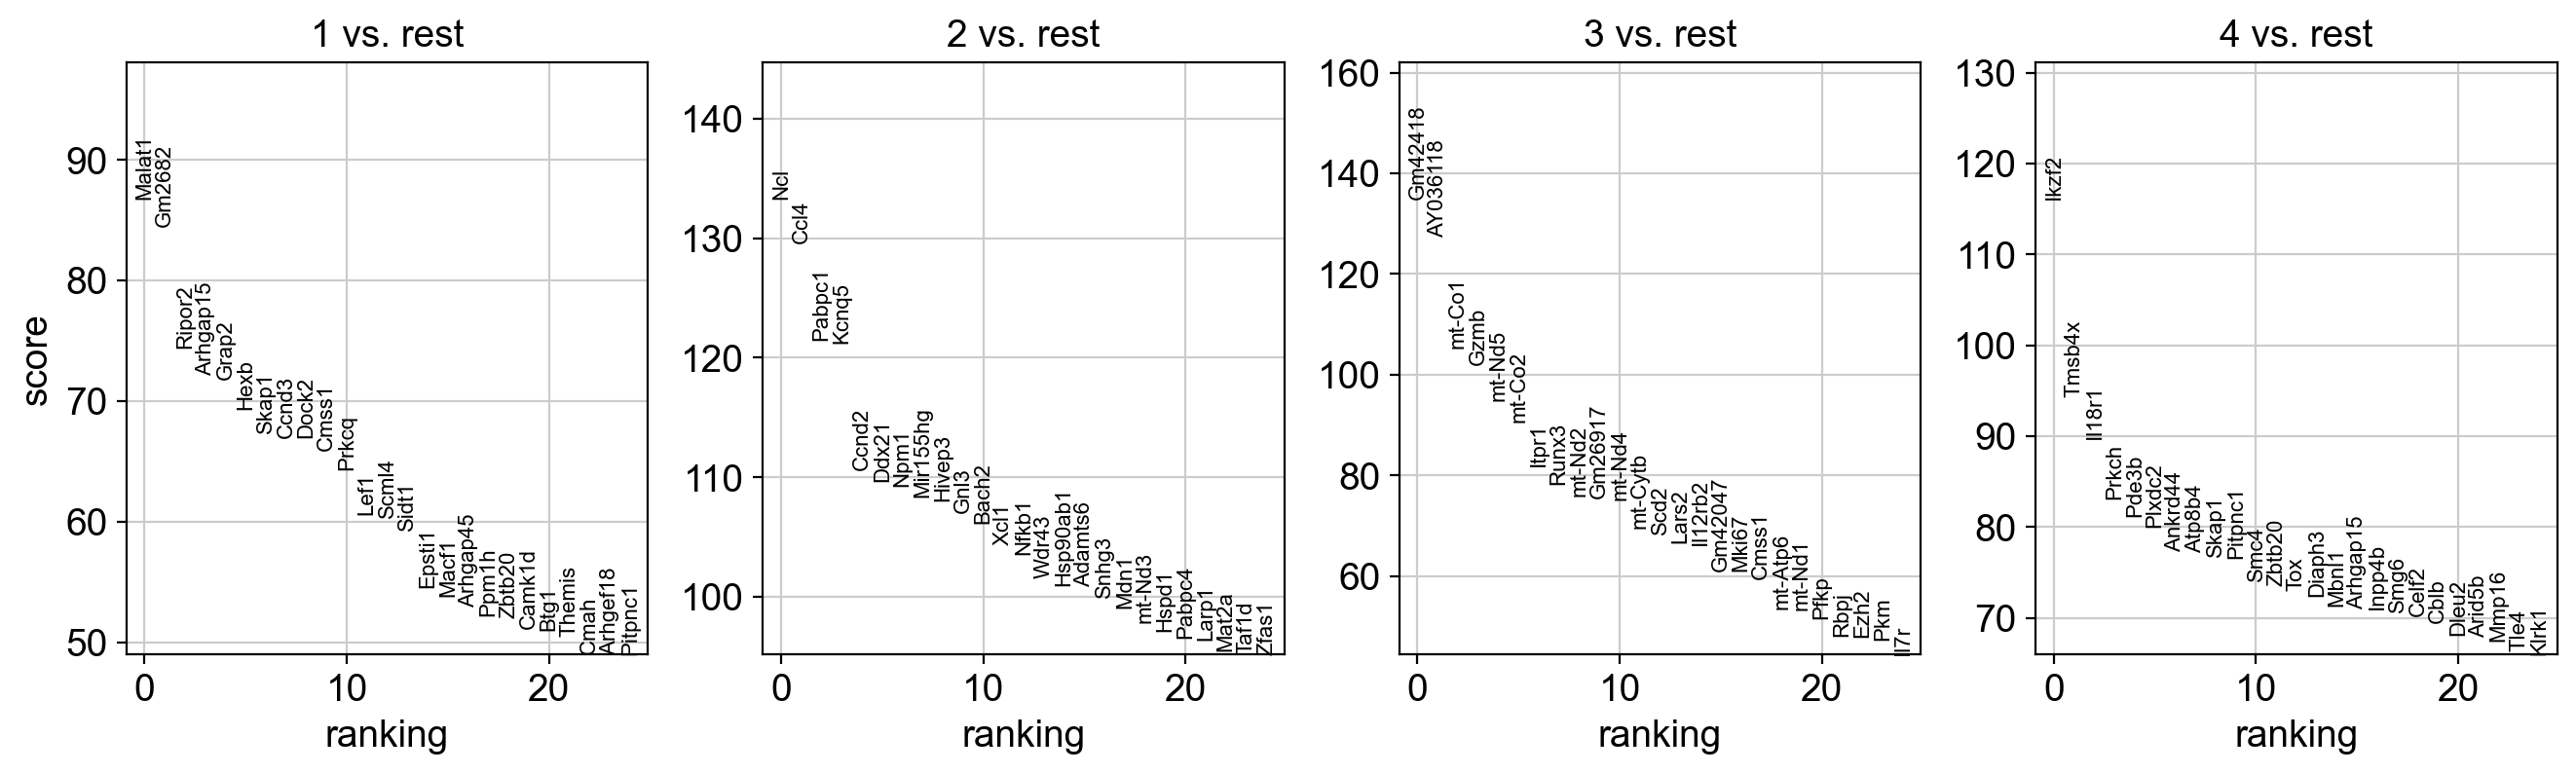

In [ ]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
#sc.tl.rank_genes_groups(adata, "leiden", mask_var="highly_variable", n_genes=25, method="t-test")
sc.set_figure_params(dpi=100)
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

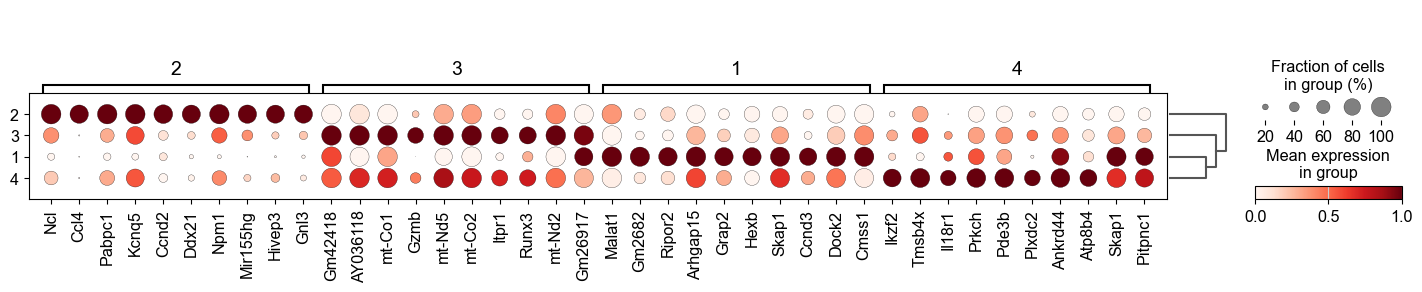

In [59]:
# Visualize the top 5 differentially-expressed genes on a dotplot.
sc.set_figure_params(dpi=50)
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden", standard_scale="var", n_genes=10)

In [52]:
# Extract differentially expressed genes
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group="1")["names"].head(5)

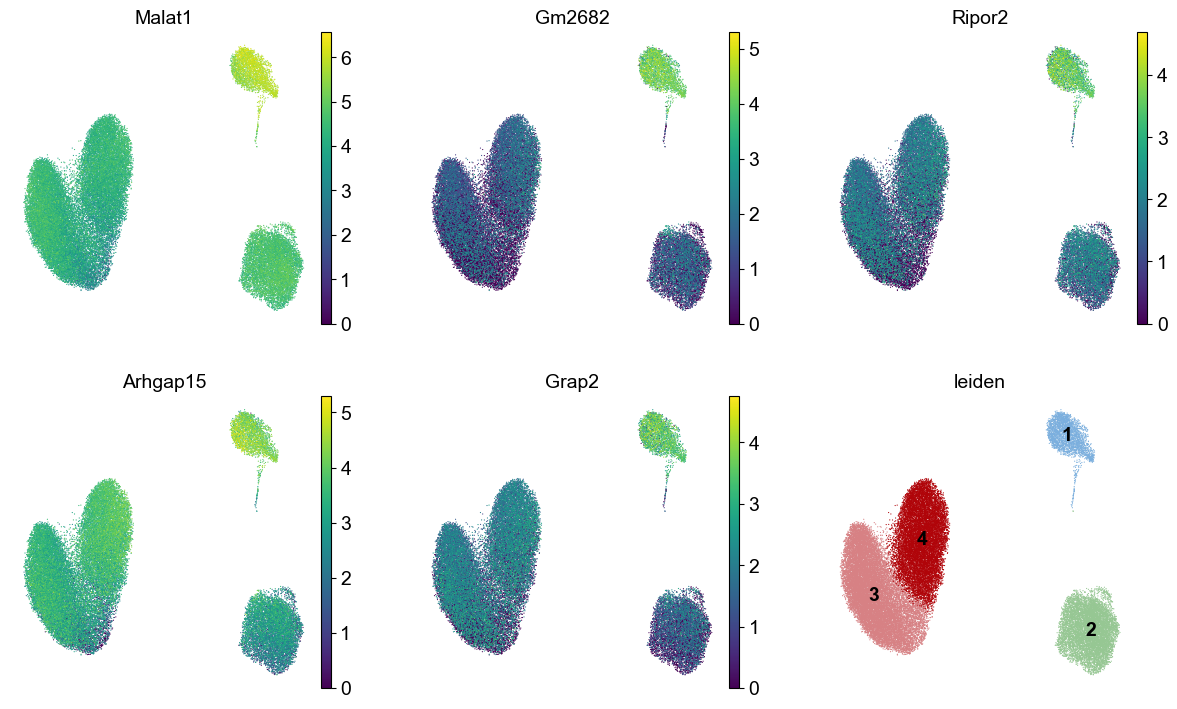

In [53]:
# Plot DEGs
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, "leiden"],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)

In [54]:
# Show the 10 top ranked genes per cluster
pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(10)

,1,2,3,4
0,Malat1,Ncl,Gm42418,Ikzf2
1,Gm2682,Ccl4,AY036118,Tmsb4x
2,Ripor2,Pabpc1,mt-Co1,Il18r1
3,Arhgap15,Kcnq5,Gzmb,Prkch
4,Grap2,Ccnd2,mt-Nd5,Pde3b
5,Hexb,Ddx21,mt-Co2,Plxdc2
6,Skap1,Npm1,Itpr1,Ankrd44
7,Ccnd3,Mir155hg,Runx3,Atp8b4
8,Dock2,Hivep3,mt-Nd2,Skap1
9,Cmss1,Gnl3,Gm26917,Pitpnc1


In [55]:
# # Compare to a single cluster
# sc.tl.rank_genes_groups(adata, groupby="leiden", groups=["0"], reference="1", method="wilcoxon")
# sc.pl.rank_genes_groups(adata, groups=["0"], n_genes=20)

## Individual gene expression

In [56]:
# # Expression on violin plot
# sc.pl.rank_genes_groups_violin(adata, groups="1", n_genes=10)
# sc.pl.violin(adata, ["Tcf7", "Sell", "Ccr7", "Gzmb"], groupby="leiden")

In [57]:
# # Expression on stacked violin plot
# sc.pl.stacked_violin(adata, marker_genes, groupby="leiden")